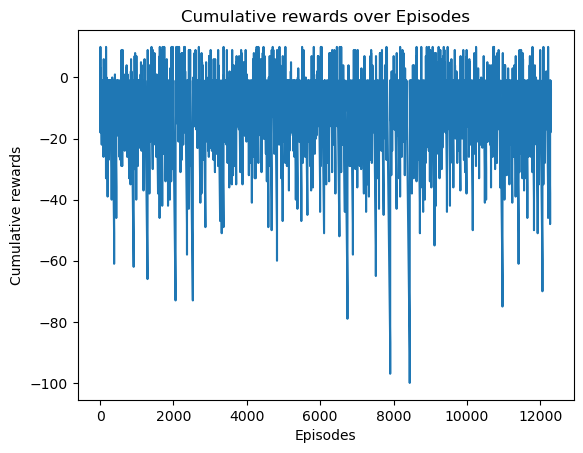

In [3]:
# Setup the environment
import numpy as np
import matplotlib.pyplot as plt

# Define the grid_size and number if states
grid_size = 5
n_states = grid_size * grid_size
# Define the reward structure: -1 for all stages, +10 for the goal, -10 for the pitfall
rewards = np.full((n_states,), -1)
rewards[24] = 10
rewards[12] = -10

# Train the agent using Q-learning
# Define the number of actions 
n_actions = 4

def epsilon_greedy_action(Q_table, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(0, Q_table.shape[1])
    else: 
        return np.argmax(Q_table[state])

alpha = 0.1
gamma = 0.9
epsilon = 0.1

Q_table = np.zeros((n_states, n_actions))

# Training Loop
for episode in range (1000):
    state = np.random.randint(0, n_states)
    done = False
    while not done :
        action = epsilon_greedy_action(Q_table, state, epsilon)
        next_state = np.random.randint(0, n_states)
        reward = rewards[next_state]

        # Q-learning update the rule
        Q_table[state, action] = Q_table[state, action] + alpha * (reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action])
        state = next_state
        if next_state == 24 or next_state ==12:
            done = True

# Apply the evaluation metrics
# Calculate the cumulative rewards
cumulative_rewards = []
for episode in range(1000):
    total_reward = 0 
    state = np.random.randint(0, n_states)
    done = False
    while not done :
        action = epsilon_greedy_action(Q_table, state, epsilon)
        next_state= np.random.randint(0, n_states)
        reward =rewards[next_state]
        total_reward += reward
        state = next_state
        if next_state == 24 or next_state == 12:
            done  = True 
        cumulative_rewards.append(total_reward)

# plot the cumulative rewards over episods
plt.plot(cumulative_rewards)
plt.xlabel('Episodes')
plt.ylabel('Cumulative rewards')
plt.title('Cumulative rewards over Episodes')
plt.show()

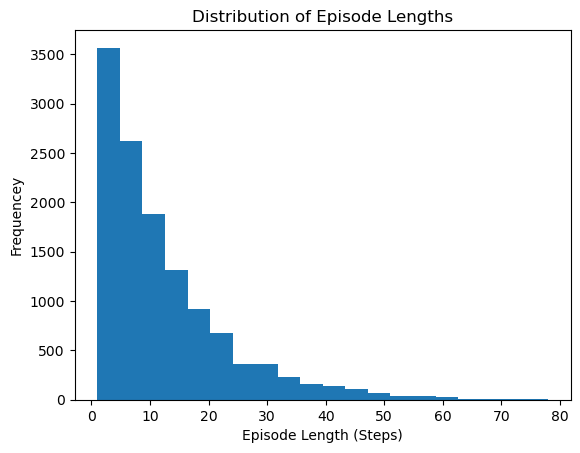

In [5]:
# Evaluate the Episode length metric
episode_lengths = []
actions = []
for episode in range(1000):
    steps = 0
    state = np.random.randint(0, n_states)
    done = False
    while not done :
        action = epsilon_greedy_action(Q_table, state, epsilon)
        next_state = np.random.randint(0, n_states)
        steps += 1
        state = next_state
        if next_state == 24 or next_state == 12:
            done = True

        episode_lengths.append(steps)

# plot a histogramm of episodes length 
plt.hist(episode_lengths, bins = 20)
plt.xlabel('Episode Length (Steps)')
plt.ylabel('Frequencey')
plt.title('Distribution of Episode Lengths')
plt.show()

In [9]:
# Redefine epsilon_greedy_ action to log exploration & exploitation
actions = []
def epsilon_greedy_action(Q_table, state, epsilon):
    if np.random.rand() < epsilon: 
        actions.append('explore')
        return np.random.randint(0, Q_table.shape[1])
    else:
        actions.append('exploit')
        return np.argmax(Q_table[state])

# Calculate and store the cumulative rewards and actions
cumulative_rewards = []
for episode in range(1000):
    total_reward =0
    state = np.random.randint(0, n_states)
    done = False
    while not done :
        action = epsilon_greedy_action(Q_table, state, epsilon)
        next_state = np.random.randint(0, n_states)
        reward = rewards[next_state]
        total_reward += reward
        state = next_state
        if next_state ==24 or next_state ==12:
            done = True
    cumulative_rewards.append(total_reward)

# Calculate success rate 
success_count = sum(1 for reward in cumulative_rewards if reward >= 10)
success_rate = success_count / len(cumulative_rewards)
# Exploration & Exploitation
exploration_count = sum(1 for action in actions if action == 'explore')
exploitation_count = sum(1 for action in actions if action == 'exploit')
exploration_exploitation_ratio = exploration_count / (exploration_count + exploitation_count)

print(f"Success Rate: {success_rate * 100}%")
print(f"Exploration vs Exploitation ratio: {exploration_exploitation_ratio}")

Success Rate: 4.3%
Exploration vs Exploitation ratio: 0.1015007261578183
